<a href="https://colab.research.google.com/github/pablo-arantes/ParametrizANI/blob/main/ParametrizANI_RESP_charges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ParametrizANI: Fast, Accurate and Free Parametrization for Small Molecules**

We have found ourselves several times in a situation where we have to parametrize compounds for running Molecular Dynamics Simulations.
This Jupyter notebook provides a practical protocol to parametrize small molecules for GAFF force field using state-of-the-art reference methods such as [**TorchANI**](https://aiqm.github.io/torchani/), [**AIMNet2**](https://github.com/isayevlab/AIMNet2), [**MACE-OFF**](https://github.com/ACEsuit/mace) or [**GFN2-xTB**](https://github.com/grimme-lab/xtb).


The main goal of this notebook is to demonstrate how to harness the power of cloud-computing to parametrize compounds in a cheap and yet feasible fashion.

---

 **This notebook is NOT a standard protocol for parametrization!** It is just simple parametrization pipeline illustrating each step of a protocol.

---

**IMPORTANT**: Please set the runtime type to CPU. Using the GPU runtime may cause execution errors.

**Bugs**
- If you encounter any bugs, please report the issue to https://github.com/pablo-arantes/ParametrizANI/issues

**Acknowledgments**

- We would like to express our gratitude to the team behind [Rotational Profiler](https://rotprof.lncc.br/index.php), especially [Victor H. Rusu](https://www.linkedin.com/in/victor-holanda-rusu-463766b2/) and [Roberto D. Lins](https://www.linkedin.com/in/roberto-lins-49477710/), for their dedication in developing the code and making it permanently available to the community.

- We would like to thank the OpenMM team for developing an excellent and open source engine.

- We would like to thank the [Psi4](https://psicode.org/) team for developing an excellent and open source suite of ab initio quantum chemistry.

- We would like to thank the [Roitberg](https://roitberg.chem.ufl.edu/) team for developing the fantastic [TorchANI](https://github.com/aiqm/torchani).

- We would like to thank the [Olexandr Isayev](https://twitter.com/olexandr) team for developing the fantastic [AIMNet2](https://github.com/isayevlab/AIMNet2).

- We would like to thank the [Xavier Barril](http://www.ub.edu/bl/) team for their protocol on dihedrals parametrization.

- We would like to thank [iwatobipen](https://twitter.com/iwatobipen) for his fantastic [blog](https://iwatobipen.wordpress.com/) on chemoinformatics.

- Also, credit to [David Koes](https://github.com/dkoes) for his awesome [py3Dmol](https://3dmol.csb.pitt.edu/) plugin.

- Finally, we would like to thank [Making it rain](https://github.com/pablo-arantes/making-it-rain) team, **Pablo R. Arantes** ([@pablitoarantes](https://twitter.com/pablitoarantes)), **Marcelo D. Polêto** ([@mdpoleto](https://twitter.com/mdpoleto)), **Conrado Pedebos** ([@ConradoPedebos](https://twitter.com/ConradoPedebos)) and **Rodrigo Ligabue-Braun** ([@ligabue_braun](https://twitter.com/ligabue_braun)), for their amazing work.

- For related notebooks see: https://github.com/pablo-arantes/ParametrizANI

# **Setting the environment for the calculation**

Firstly, we need to install all necessary libraries and packages for our protocol. The main packages we will be installing are:

1.    Anaconda (https://docs.conda.io/en/latest/miniconda.html)
2.    RDKit (https://www.rdkit.org/)
3.    py3Dmol (https://pypi.org/project/py3Dmol/)
4.    Numpy (https://numpy.org/)
5.    Matplotlib (https://matplotlib.org/)
6.    TorchANI (https://aiqm.github.io/torchani/)
7.    AIMNet2 (https://github.com/isayevlab/AIMNet2)

In [43]:
#@title **Install Conda Colab**
#@markdown It will restart the kernel (session), don't worry.
# !pip install -q condacolab
# import condacolab
# condacolab.install()

!pip install -q condacolab
import condacolab
condacolab.install_from_url("https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh")

✨🍰✨ Everything looks OK!


In [1]:
#@title **Install dependencies**
#@markdown It will take a few minutes, please, drink a coffee and wait. ;-)
# install dependencies
import subprocess
import sys
subprocess.run("pip -q install py3Dmol", shell=True)
subprocess.run("mamba install -c conda-forge ambertools -y", shell=True)
subprocess.run("pip install ase", shell=True)
subprocess.run("mamba install -c conda-forge rdkit -y", shell=True)
subprocess.run("mamba install -c conda-forge openbabel -y", shell=True)
subprocess.run("pip install torchani", shell=True)
subprocess.run("conda install -c conda-forge xtb-python -y", shell=True)
subprocess.run("git clone https://github.com/pablo-arantes/AIMNet2.git", shell=True)

CompletedProcess(args='git clone https://github.com/pablo-arantes/AIMNet2.git', returncode=0)

In [2]:
%%bash
#@title **Install dependencies for Psi4**
mamba create -n psi4_env python=3.11 psi4 resp -c conda-forge --yes > /dev/null 2>&1
source activate psi4_env > /dev/null 2>&1
pip install rdkit > /dev/null 2>&1
pip install Cython > /dev/null 2>&1
mamba install -c conda-forge parmed  --yes > /dev/null 2>&1
mamba install -c bioconda pybel --yes > /dev/null 2>&1
mamba install -c conda-forge openbabel --yes > /dev/null 2>&1

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Smiles: C(C(COP(=O)([OH])[O-])O)O
Charge = -1


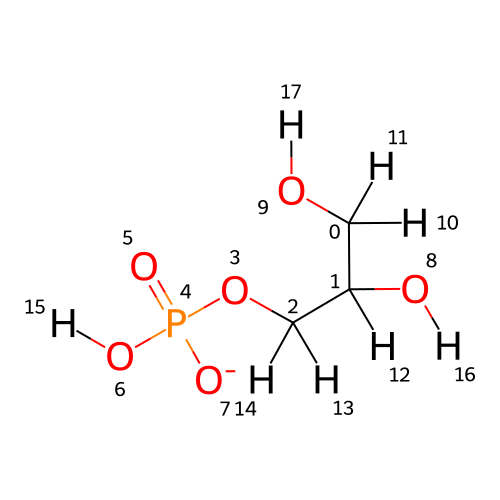

In [77]:
#@title **Please Provide the Required Information for Your Molecule**

#@markdown Enter the SMILES string or filename of your molecule (supported formats: PDB or MOL).
#@markdown **Examples:** `C=CC(=O)OC`, `molecule.pdb`, or `molecule.mol`.

#@markdown If you want to use a PDB or MOL file, please make sure to upload the file to this Colab session first.

#@markdown If you are unsure of the exact SMILES notation, you can search for it at [PubChem](https://pubchem.ncbi.nlm.nih.gov/).

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdMolTransforms
from rdkit.Chem import rdForceFieldHelpers
from rdkit.Chem import rdmolfiles
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdDepictor
from IPython.display import SVG
import ipywidgets as widgets
import rdkit
from rdkit.Chem.Draw import IPythonConsole
AllChem.SetPreferCoordGen(True)
from IPython.display import Image
from openbabel import pybel
import py3Dmol

import os

def mol_with_atom_index(mol):
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx())
    return mol

import py3Dmol


Type = "smiles" #@param ["smiles", "pdb", "mol"]

smiles_or_filename = 'C(C(COP(=O)([OH])[O-])O)O' #@param {type:"string"}
workDir = "/content/"

# Function to extract atom information from PDB file
def extract_atom_info_from_pdb(pdb_file_path):
    atom_info = []
    with open(pdb_file_path, 'r') as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                atom_number = int(line[6:11].strip())
                atom_name = line[12:16].strip()
                element = line[76:78].strip()
                x = float(line[30:38].strip())
                y = float(line[38:46].strip())
                z = float(line[46:54].strip())
                atom_info.append((atom_number-1, atom_name, element, x, y, z))
    return atom_info

if Type == "smiles":
  Smiles = smiles_or_filename
  smiles_fig = Chem.MolFromSmiles(Smiles)
  hmol = Chem.AddHs(smiles_fig)
  hmol2D = Chem.AddHs(smiles_fig)

  # AllChem.EmbedMolecule(hmol)
  # AllChem.UFFOptimizeMolecule(hmol)
  # pdb_block = Chem.MolToPDBBlock(hmol)
  # with open('ini.pdb', 'w') as file:
  #   file.write(pdb_block)
elif Type == "pdb":
  mol= [m for m in pybel.readfile(filename=smiles_or_filename, format='pdb')][0]
  out=pybel.Outputfile(filename='mol.mol',format='mol',overwrite=True)
  out.write(mol)
  out.close()
  mol = Chem.MolFromMolFile('mol.mol')
  Smiles = Chem.MolToSmiles(mol)
  smiles_fig = Chem.MolFromSmiles(Smiles)
  hmol = Chem.AddHs(smiles_fig)
else:
  mol = Chem.MolFromMolFile(smiles_or_filename)
  Smiles = Chem.MolToSmiles(mol)
  smiles_fig = Chem.MolFromSmiles(Smiles)
  hmol = Chem.AddHs(smiles_fig)

original_stdout = sys.stdout # Save a reference to the original standard output
final_smiles = '/content/smiles.smi'
with open(final_smiles, 'w') as f:
    sys.stdout = f # Change the standard output to the file we created.
    print(Smiles, ' ')
    sys.stdout = original_stdout



mol = Chem.MolFromSmiles(Smiles)
new_match = hmol.GetSubstructMatch(mol)
hmol = Chem.AddHs(mol)
AllChem.EmbedMolecule(hmol)
mp = rdForceFieldHelpers.MMFFGetMoleculeProperties(hmol)
ff = rdForceFieldHelpers.MMFFGetMoleculeForceField(hmol, mp)
AllChem.OptimizeMolecule(ff, maxIters=200)
ff.Minimize()
AllChem.MolToMolFile(hmol, (os.path.join(workDir, "smiles_min.mol")))
AllChem.MolToPDBFile(hmol, (os.path.join(workDir, "smiles_min.pdb")))
ob_mol = pybel.readstring("mol", Chem.MolToMolBlock(hmol))

# Write to MOL2 file
ob_mol.write("mol2", "smiles_min.mol2", overwrite=True)
### set new partial charges
charge_mol = Chem.rdPartialCharges.ComputeGasteigerCharges(hmol)
charges = Chem.GetFormalCharge(hmol)

# Function to extract atom information from PDB file
def extract_atom_info_from_pdb(pdb_file_path):
    atom_info = []
    with open(pdb_file_path, 'r') as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                atom_number = int(line[6:11].strip())
                atom_name = line[12:16].strip()
                element = line[76:78].strip()
                x = float(line[30:38].strip())
                y = float(line[38:46].strip())
                z = float(line[46:54].strip())
                atom_info.append((atom_number-1, atom_name, element, x, y, z))
    return atom_info

# Read atom information from PDB file
pdb_file_path = os.path.join(workDir, "smiles_min.pdb")  # Replace with your actual PDB file path
atom_info = extract_atom_info_from_pdb(pdb_file_path)

# Initialize Py3Dmol view
view = py3Dmol.view(width=800, height=600)

# Load the PDB file to Py3Dmol
with open(pdb_file_path, 'r') as f:
    pdb_data = f.read()
view.addModel(pdb_data,'pdb', {'keepH':'true'})

# Add stick representation
view.setStyle({'model': -1}, {'stick': {'radius': 0.15}, 'sphere': {'radius': 0.5}})

# Add labels for atom numbers and names, skipping hydrogens
for atom_number, atom_name, element, x, y, z in atom_info:
    # if element != 'H':
        # label = f"{atom_name} ({atom_number})"
        label = f"{atom_number}"

        view.addLabel(label, {"position": {"x": x, "y": y, "z": z}, "fontColor": "white", "backgroundColor": "transparent", "fontSize": 14})

# Additional configurations
view.setBackgroundColor("white")
view.zoomTo()

# Show the view
view.show()

d2d = rdMolDraw2D.MolDraw2DSVG(500, 500)
d2d.drawOptions().addAtomIndices=True
d2d.DrawMolecule(hmol2D)
d2d.FinishDrawing()
svg = d2d.GetDrawingText()
with open('smiles.svg', 'w') as f:
    f.write(svg)
print("Smiles: " + str(Smiles))
print("Charge = " + str(charges))

SVG(svg)


In [78]:
#@title **Geometry Optimization using TorchANI, AIMNet2, or GFN2-xTB**:

#@markdown Optimization calculation of each molecule, using **TorchANI**, **AIMNet2** or **GFN2-xTB** as the optimizing engine. Iteratively adjusts the molecular geometry to find the lowest energy structure before calculating properties.


#@markdown ANI is a general-purpose neural network-based atomistic potential for organic molecules. Four ANI models have been published, the ANI-1, ANI-1x, ANI-1ccx, and ANI-2x potentials. The ANI-1 model was developed by random sampling conformational space of 57k organic molecules with up to eight heavy atoms, C, N, and O, plus H atoms to have proper chemistry, then running DFT calculations to obtain potential energies for training. ANI-1x was trained to a data set of molecular conformations sampled through an active learning scheme. Active learning is where the model itself is iteratively used to decide what new data should be included in the next iteration. ANI-1ccx was trained to the ANI-1x data set, then retrained to a 10% smaller data set of accurate coupled cluster calculations, resulting in a potential that outperformed DFT in test cases. ANI-2x was trained by adding many millions of data points to the ANI-1x data set, at the same level of theory, but including elements S, F, and Cl. We included the **ANI-1x**, **ANI-1ccx**, and **ANI-2x** models in our notebook.

#@markdown We have now integrated TorchANI2 into our pipeline, along with the latest improved ANI models trained on the expanded 2× dataset (**ANI-2xr, ANI-2dr, ANI-2xr-Snn, and ANI-mbis**). These models were trained at the B97-3c level of theory and include explicit repulsion and dispersion corrections, smoother potential energy surfaces (PES), and MBIS-derived charges.

#@markdown If you want to know more about **TorchANI**, please, check at https://aiqm.github.io/torchani/

#@markdown The AIMNet2 (a general-purpose neural netrork potential for organic and element-organic molecules) models are applicable for systems containing the following set of chemical elements: H, B, C, N, O, F, Si, P, S, Cl, As, Se, Br, I, both neutral and charged. The models aim to reproduce RKS B97-3c and wB97M-D3 energies.

#@markdown If you want to know more about **AIMNet2**, please, check at https://github.com/isayevlab/AIMNet2

#@markdown GFN2-xTB is an extended semiempirical tight-binding model primarily designed for the fast calculation of structures and noncovalent interaction energies for molecular systems with roughly 1000 atoms, notably including anisotropic second-order density fluctuation effects via cumulative atomic multipole moments and a self-consistent D4 London dispersion model.

#@markdown If you want to know more about **GFN2-xTB**, please, check at https://github.com/grimme-lab/xtb

#@markdown Please, select your model:
model_name = "wB97M-D3" #@param ["ANI-1x", "ANI-1ccx", "ANI-2x", "ANI-2xr", "ANI-2dr", "ANI-2xr-Snn","ANI-mbis", "B97-3c", "wB97M-D3", "GFN2-xTB"]

#@markdown Convergence threshold for geometry optimization:

opt_tol = 0.0001 #@param {type:"slider", min:0.0001, max:0.1, step:0.0001}

# @markdown **IMPORTANT:** TorchANI currently supports only neutral molecules.
# @markdown Charged species are not supported.
# @markdown For charged molecules, please use AIMNet2 or GFN2-xTB instead.

import os
import re
import torch
import numpy as np
from ase import Atoms
from ase.optimize import BFGS, LBFGS
from ase.io import read, write
from ase.constraints import FixInternals
from openbabel import pybel
from openbabel import openbabel
import torch
import torchani
from torchani.units import HARTREE_TO_KCALMOL
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Geometry import Point3D
from google.colab import files
import sys
import torch.nn.functional as F
import ase.calculators.calculator

class AIMNet2Calculator(ase.calculators.calculator.Calculator):
    """ ASE calculator for AIMNet2 model
    Arguments:
        model (:class:`torch.nn.Module`): AIMNet2 model
        charge (int or float): molecular charge.  Default: 0
    """

    implemented_properties = ['energy', 'forces', 'free_energy', 'charges']

    def __init__(self, model, charge=0):
        super().__init__()
        self.model = model
        self.charge = charge
        self.device = next(model.parameters()).device
        cutoff = max(v.item() for k, v in model.state_dict().items() if k.endswith('aev.rc_s'))
        self.cutoff = float(cutoff)
        self._t_numbers = None
        self._t_charge = None

    def do_reset(self):
        self._t_numbers = None
        self._t_charge = None
        self.charge = 0.0

    def set_charge(self, charge):
        self.charge = float(charge)

    def _make_input(self):
        coord = torch.as_tensor(self.atoms.positions).to(torch.float).to(self.device).unsqueeze(0)
        if self._t_numbers is None:
            self._t_numbers = torch.as_tensor(self.atoms.numbers).to(torch.long).to(self.device).unsqueeze(0)
            self._t_charge = torch.tensor([self.charge], dtype=torch.float, device=self.device)
        d = dict(coord=coord, numbers=self._t_numbers, charge=self._t_charge)
        return d

    def _eval_model(self, d, forces=True):
        prev = torch.is_grad_enabled()
        torch._C._set_grad_enabled(forces)
        if forces:
            d['coord'].requires_grad_(True)
        _out = self.model(d)
        ret = dict(energy=_out['energy'].item(), charges=_out['charges'].detach()[0].cpu().numpy())
        if forces:
            if 'forces' in _out:
                f = _out['forces'][0]
            else:
                f = - torch.autograd.grad(_out['energy'], d['coord'])[0][0]
            ret['forces'] = f.detach().cpu().numpy()
        torch._C._set_grad_enabled(prev)
        return ret

    def calculate(self, atoms=None, properties=['energy'],
                  system_changes=ase.calculators.calculator.all_changes):
        super().calculate(atoms, properties, system_changes)
        _in = self._make_input()
        do_forces = 'forces' in properties
        _out =  self._eval_model(_in, do_forces)

        self.results['energy'] = _out['energy']
        self.results['charges'] = _out['charges']
        if do_forces:
            self.results['forces'] = _out['forces']


# Define utility functions
def mol2arr(mols, device):
    coordinates = []
    spices = []
    for mol in mols:
        pos = mol.GetConformer().GetPositions().tolist()
        atomnums = [a.GetAtomicNum() for a in mol.GetAtoms()]
        coordinates.append(pos)
        spices.append(atomnums)
    coordinates = torch.tensor(coordinates, requires_grad=True, device=device)
    species = torch.tensor(spices, device=device)
    return coordinates, species

def pybel2atoms(mol):
    coord = np.array([a.coords for a in mol.atoms])
    numbers = np.array([a.atomicnum for a in mol.atoms])
    atoms = Atoms(positions=coord, numbers=numbers)
    return atoms

def update_mol(mol, atoms, align=True):
    mol_old = pybel.Molecule(pybel.ob.OBMol(mol.OBMol))
    for i, c in enumerate(atoms.get_positions()):
        mol.OBMol.GetAtom(i+1).SetVector(*c.tolist())
    if align:
        aligner = pybel.ob.OBAlign(False, False)
        aligner.SetRefMol(mol_old.OBMol)
        aligner.SetTargetMol(mol.OBMol)
        aligner.Align()
        aligner.UpdateCoords(mol.OBMol)

def guess_pybel_type(filename):
    return os.path.splitext(filename)[1][1:]

def guess_charge(mol):
    m = re.search('charge: (-?\d+)', mol.title)
    return int(m.group(1)) if m else mol.charge

def convert_mol_to_xyz(mol_file_path, xyz_file_path):
    obConversion = openbabel.OBConversion()
    obConversion.SetInAndOutFormats("mol", "xyz")
    mol = openbabel.OBMol()
    obConversion.ReadFile(mol, mol_file_path)
    obConversion.WriteFile(mol, xyz_file_path)

def optimize(atoms, prec=1e-3, steps=1000, traj=None):
    with torch.jit.optimized_execution(False):
        opt = LBFGS(atoms, trajectory=traj)
        opt.run(prec, steps)

workDir = "/content"  # Define working directory

# Set device for TorchANI
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model selection and setup
if model_name in ["ANI-1x", "ANI-1ccx", "ANI-2x", "ANI-2xr", "ANI-2dr", "ANI-2xr-Snn","ANI-mbis"]:
    if model_name == "ANI-2x":
        model = torchani.models.ANI2x(periodic_table_index=True).to(device)
        calculator = torchani.models.ANI2x().ase()
    elif model_name == "ANI-1ccx":
        model = torchani.models.ANI1ccx(periodic_table_index=True).to(device)
        calculator = torchani.models.ANI1ccx().ase()
    elif model_name == "ANI-1x":
        model = torchani.models.ANI1x(periodic_table_index=True).to(device)
        calculator = torchani.models.ANI1x().ase()
    elif model_name == "ANI-mbis":
        model = torchani.models.ANImbis(periodic_table_index=True).to(device)
        calculator = torchani.models.ANImbis().ase()
    elif model_name == "ANI-2dr":
        model = torchani.models.ANI2dr(periodic_table_index=True).to(device)
        calculator = torchani.models.ANI2dr().ase()
    elif model_name == "ANI-2xr-Snn":
        model = torchani.models.SnnANI2xr(periodic_table_index=True).to(device)
        calculator = torchani.models.SnnANI2xr().ase()
    else:
        model = torchani.models.ANI2xr(periodic_table_index=True).to(device)
        calculator = torchani.models.ANI2xr().ase()
    print(f"Model = {model_name}")
elif model_name in ["B97-3c", "wB97M-D3"]:
    folder_path = '/content/AIMNet2/calculators/'
    sys.path.append(folder_path)
    if model_name == "wB97M-D3":
        model_file = '/content/AIMNet2/models/aimnet2_wb97m-d3_ens.jpt'
    else:
        model_file = '/content/AIMNet2/models/aimnet2_b973c_ens.jpt'
    print('Loading AIMNet2 model from file', model_file)
    model = torch.jit.load(model_file, map_location=device)
    calc = AIMNet2Calculator(model)
elif model_name in ["GFN2-xTB"]:
    from xtb.ase.calculator import XTB
    calc = XTB(method="GFN2-xTB")
    print(f"Model = {model_name}")

mol_file_path = os.path.join(workDir, "smiles_min.mol")
mol_deg = AllChem.MolFromMolFile(mol_file_path, removeHs=False)

if model_name in ["ANI-1x", "ANI-1ccx", "ANI-2x", "ANI-2xr", "ANI-2dr", "ANI-2xr-Snn", "ANI-mbis"]:
    coordinates, species = mol2arr([mol_deg], device)
    atoms = read(mol_file_path)
    tensor1 = coordinates.detach().numpy()
    atoms.set_positions(tensor1[0])
    atoms.set_calculator(calculator)
    opt = LBFGS(atoms)
    opt.run(fmax=opt_tol)
    write(os.path.join(workDir, f"smiles_min_ML.xyz"), format="xyz", images=atoms)

    # Conversion from XYZ to MOL and PDB
    atomic_symbols = []
    xyz_coordinates = []
    with open(os.path.join(workDir, f"smiles_min_ML.xyz"), "r") as file:
        for line_number, line in enumerate(file):
            if line_number == 0:
                num_atoms = int(line)
            elif line_number == 1:
                comment = line
            else:
                atomic_symbol, x, y, z = line.split()
                atomic_symbols.append(atomic_symbol)
                xyz_coordinates.append([float(x), float(y), float(z)])

    conf = mol_deg.GetConformer()
    for i in range(mol_deg.GetNumAtoms()):
        x, y, z = xyz_coordinates[i]
        conf.SetAtomPosition(i, Point3D(x, y, z))
    AllChem.MolToMolFile(mol_deg, os.path.join(workDir, f"smiles_min_ML.mol"))
    AllChem.MolToPDBFile(mol_deg, os.path.join(workDir, f"smiles_min_ML.pdb"))

elif model_name in ["B97-3c", "wB97M-D3"]:
    xyz_file_path = os.path.join(workDir,  f"smiles_min.xyz")
    convert_mol_to_xyz(mol_file_path, xyz_file_path)
    out_file = os.path.join(workDir, f"smiles_min_ML.xyz")
    with open(out_file, 'w') as f:
        for mol in pybel.readfile(guess_pybel_type(xyz_file_path), xyz_file_path):
            atoms = pybel2atoms(mol)
            mol_charge = guess_charge(mol)
            calc.do_reset()
            calc.set_charge(mol_charge)
            atoms.set_calculator(calc)
            optimize(atoms, prec=opt_tol, steps=2000)
            update_mol(mol, atoms, align=False)
            f.write(mol.write(guess_pybel_type(out_file)))
            f.flush()

    # Conversion from XYZ to MOL and PDB
    atomic_symbols = []
    xyz_coordinates = []
    with open(os.path.join(workDir, f"smiles_min_ML.xyz"), "r") as file:
        for line_number, line in enumerate(file):
            if line_number == 0:
                num_atoms = int(line)
            elif line_number == 1:
                comment = line
            else:
                atomic_symbol, x, y, z = line.split()
                atomic_symbols.append(atomic_symbol)
                xyz_coordinates.append([float(x), float(y), float(z)])

    conf = mol_deg.GetConformer()
    for i in range(mol_deg.GetNumAtoms()):
        x, y, z = xyz_coordinates[i]
        conf.SetAtomPosition(i, Point3D(x, y, z))
    AllChem.MolToMolFile(mol_deg, os.path.join(workDir, f"smiles_min_ML.mol"))
    AllChem.MolToPDBFile(mol_deg, os.path.join(workDir, f"smiles_min_ML.pdb"))
elif model_name in ["GFN2-xTB"]:
    coordinates, species = mol2arr([mol_deg], device)
    atoms = read(mol_file_path)
    tensor1 = coordinates.detach().numpy()
    atoms.set_positions(tensor1[0])
    atoms.set_calculator(calc)
    opt = LBFGS(atoms)
    opt.run(fmax=opt_tol)
    write(os.path.join(workDir, f"smiles_min_ML.xyz"), format="xyz", images=atoms)

    # Conversion from XYZ to MOL and PDB
    atomic_symbols = []
    xyz_coordinates = []
    with open(os.path.join(workDir, f"smiles_min_ML.xyz"), "r") as file:
        for line_number, line in enumerate(file):
            if line_number == 0:
                num_atoms = int(line)
            elif line_number == 1:
                comment = line
            else:
                atomic_symbol, x, y, z = line.split()
                atomic_symbols.append(atomic_symbol)
                xyz_coordinates.append([float(x), float(y), float(z)])

    conf = mol_deg.GetConformer()
    for i in range(mol_deg.GetNumAtoms()):
        x, y, z = xyz_coordinates[i]
        conf.SetAtomPosition(i, Point3D(x, y, z))
    AllChem.MolToMolFile(mol_deg, os.path.join(workDir, f"smiles_min_ML.mol"))
    AllChem.MolToPDBFile(mol_deg, os.path.join(workDir, f"smiles_min_ML.pdb"))

<>:147: SyntaxWarning: invalid escape sequence '\d'
<>:147: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1544329372.py:147: SyntaxWarning: invalid escape sequence '\d'
  m = re.search('charge: (-?\d+)', mol.title)


Loading AIMNet2 model from file /content/AIMNet2/models/aimnet2_wb97m-d3_ens.jpt


/tmp/ipython-input-1544329372.py:250: FutureWarning: Please use atoms.calc = calc
  atoms.set_calculator(calc)


       Step     Time          Energy          fmax
LBFGS:    0 13:51:03   -24823.802033        1.239841
LBFGS:    1 13:51:03   -24823.888669        0.687269
LBFGS:    2 13:51:03   -24823.928071        0.391898
LBFGS:    3 13:51:03   -24823.956561        0.392610
LBFGS:    4 13:51:03   -24823.983955        0.404354
LBFGS:    5 13:51:03   -24823.999859        0.374901
LBFGS:    6 13:51:03   -24824.011363        0.260631
LBFGS:    7 13:51:03   -24824.018073        0.195748
LBFGS:    8 13:51:04   -24824.023557        0.161517
LBFGS:    9 13:51:04   -24824.028326        0.197481
LBFGS:   10 13:51:04   -24824.032859        0.186048
LBFGS:   11 13:51:04   -24824.036741        0.146890
LBFGS:   12 13:51:04   -24824.040123        0.157140
LBFGS:   13 13:51:04   -24824.042600        0.104494
LBFGS:   14 13:51:04   -24824.043846        0.075683
LBFGS:   15 13:51:04   -24824.044817        0.070087
LBFGS:   16 13:51:04   -24824.045504        0.086710
LBFGS:   17 13:51:04   -24824.046524        0.08

In [84]:
%%bash
source activate psi4_env

python
import os
import psi4
import resp
from openbabel import openbabel as ob
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import AllChem,Draw

# Minimal periodic table (expand if needed)
PERIODIC_TABLE = {
    "H": 1,  "He": 2,
    "Li": 3, "Be": 4, "B": 5,  "C": 6,  "N": 7,  "O": 8,  "F": 9,  "Ne": 10,
    "Na": 11,"Mg": 12,"Al": 13,"Si": 14,"P": 15, "S": 16, "Cl": 17,"Ar": 18,
    "K": 19, "Ca": 20,
    "Br": 35,"I": 53
}

def parse_atomic_symbols(xyz_string):
    """
    Extract atomic symbols from an XYZ string.
    Handles both standard XYZ (with atom count + comment line)
    and raw coordinate blocks.
    """
    lines = xyz_string.strip().splitlines()

    # Remove first two lines if standard XYZ format
    if lines[0].strip().isdigit():
        lines = lines[2:]

    symbols = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 4:
            symbols.append(parts[0])

    return symbols


def compute_total_electrons(symbols, charge=0):
    """
    Compute total electrons from atomic symbols and molecular charge.
    """
    total_Z = 0
    for s in symbols:
        if s not in PERIODIC_TABLE:
            raise ValueError(f"Element '{s}' not in periodic table dictionary.")
        total_Z += PERIODIC_TABLE[s]

    total_electrons = total_Z - charge
    return total_electrons


def guess_multiplicity(total_electrons):
    """
    Assign multiplicity automatically:
        odd electrons  -> doublet (2)
        even electrons -> singlet (1)
    """
    return 2 if total_electrons % 2 else 1


def build_psi4_molecule_auto(xyz_string, charge=0):
    """
    Full pipeline:
        - Parse atoms
        - Compute electrons
        - Assign multiplicity
        - Build Psi4 molecule
    """
    symbols = parse_atomic_symbols(xyz_string)
    total_electrons = compute_total_electrons(symbols, charge)
    multiplicity = guess_multiplicity(total_electrons)

    geom_block = f"{charge} {multiplicity}\n{xyz_string}"
    psi_mol = psi4.geometry(geom_block)

    return psi_mol, total_electrons, multiplicity

def cleanUp(psi4out_xyz):
    deleteTheseFiles = ['1_default_grid.dat','1_default_grid_esp.dat','grid.dat','timer.dat']
    deleteTheseFiles.append(psi4out_xyz)
    for fileName in deleteTheseFiles:
        if os.path.exists(fileName):
            os.remove(fileName)

def get_xyz_coords(mol):
    if not mol is None:
        num_atoms = mol.GetNumAtoms()
        xyz_string=""
        for counter in range(num_atoms):
            pos=mol.GetConformer().GetAtomPosition(counter)
            xyz_string = xyz_string + ("%s %12.6f %12.6f %12.6f\n" % (mol.GetAtomWithIdx(counter).GetSymbol(), pos.x, pos.y, pos.z) )
    return xyz_string


def calcRESPCharges(mol, basisSet, method, gridPsi4 = 1):
    options = {'BASIS_ESP': basisSet,
               'METHOD_ESP': method,
               'RESP_A': 0.0005,
               'RESP_B': 0.1,
               'VDW_SCALE_FACTORS':[1.4, 1.6, 1.8, 2.0],
               'VDW_POINT_DENSITY':int(gridPsi4)
    }

    # resp_charges = resp.resp([mol], [options])[0][1]
    resp_charges = resp.resp([mol], options)

    return resp_charges

#@title **Parameters to Generate RESP Partial Charges:**

method = "HF" #@param ["B3LYP", "MP2", "HF"]
#@markdown Quantum chemistry method used to calculate the molecular electrostatic potential.

#@markdown - **HF (Hartree-Fock)**: a fast, basic wavefunction method.

#@markdown - **B3LYP**: a popular hybrid Density Functional Theory (DFT) method, more accurate.

#@markdown - **MP2**: a post-Hartree-Fock method including electron correlation, usually more accurate but computationally expensive.

basisSet = "6-31G**" #@param ["STO-3g", "3-21G", "6-31G*", "6-31G**", "6-31+G(d,p)", "6-311++G(2d,p)"]
Charge = -1 #@param {type:"slider", min:-20, max:20, step:1}
#@markdown The set of functions used to describe atomic orbitals in the quantum calculation.

#@markdown Larger and more complex basis sets (like 6-311++G(2d,p)) typically give more accurate results but require more computational resources.

#@markdown The "star" (*) and plus (+) symbols indicate addition of polarization and diffuse functions, improving flexibility for electrons.
Calculation_Type = "Single Point" #@param ["Single Point", "Geometry Optimization"]
#@markdown Defines the type of quantum chemistry calculation:

#@markdown - **Single Point**: Calculates energy and properties at a fixed geometry (no structure change).

#@markdown - **Geometry Optimization**: Iteratively adjusts the molecular geometry to find the lowest energy structure before calculating properties.

if Calculation_Type == "Single Point":
  singlePoint = True
else:
  singlePoint = False

# neutralize = True
psi4.set_memory('8 GB')
obConversion = ob.OBConversion()
obConversion.SetInAndOutFormats("xyz", "mol2")
# singlePoint = True
path = '/content'

# inputFile = '/content/smiles.smi'
# molList = Chem.SDMolSupplier(inputFile, removeHs=False)

SMILESasInput = True

if SMILESasInput:
    molList = []
    inputFile = '/content/smiles.smi'
    suppl = Chem.SmilesMolSupplier(inputFile, titleLine = False)

    for mol in suppl:
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol)
        try:
            AllChem.MMFFOptimizeMolecule(mol)
        except:
            AllChem.UFFOptimizeMolecule(mol)
        molList.append(mol)

for mol in molList:
    print(mol)
    if not mol is None:

        molId = mol.GetProp("_Name")
        print('Trying:', molId)

        xyz_file = "/content/smiles_min_ML.xyz"

        with open(xyz_file, "r") as f:
            lines = f.readlines()

        xyz_coords = "".join(lines[2:])

        mol, nelec, mult = build_psi4_molecule_auto(xyz_coords, charge=int(Charge))
        psi_mol = psi4.geometry(xyz_coords)
        psi_mol.set_molecular_charge(int(Charge))
        psi_mol.set_multiplicity(mult)
        psi_mol.update_geometry()
        print("Total electrons:", nelec)
        print("Multiplicity:", mult)

        ### single point calculation
        outfile_mol2 = inputFile[:-4]+".mol2"

        if singlePoint:
            print('Running singlepoint...')
            resp_charges = calcRESPCharges(psi_mol, basisSet, method, gridPsi4 = 1)

        else:
            print('Running geometry optimization...')
            methodNbasisSet = method+"/"+basisSet
            psi4.optimize(methodNbasisSet, molecule=psi_mol)
            resp_charges = calcRESPCharges(psi_mol, basisSet, method, gridPsi4 = 1)

        ### save coords to xyz file
        psi4out_xyz = molId + '.xyz'
        psi_mol.save_xyz_file(psi4out_xyz,1)

        ### read xyz file and write as mol2
        ob_mol = ob.OBMol()
        obConversion.ReadFile(ob_mol, psi4out_xyz)

         ### write as mol2
        outfile_mol2 = path+"/"+molId+"_partialChgs.mol2"
        obConversion.WriteFile(ob_mol, outfile_mol2)

        ### set new partial charges
        count = 0
        newChg_temp = resp_charges[1]
        print("RESP Charges: ", newChg_temp)
        for atom in ob.OBMolAtomIter(ob_mol):
            newChg = newChg_temp[count]
            atom.SetPartialCharge(newChg)
            count += 1

        ### write as mol2
        outfile_mol2 = path+"/"+molId+"_partialChgs.mol2"
        outfile_pdb = path+"/"+molId+".pdb"
        print("Finished. Saved compound with partial charges as mol2 file: %s" % outfile_mol2)
        obConversion.WriteFile(ob_mol, outfile_mol2)
        ## clean up
        cleanUp(psi4out_xyz)

#draw_with_charges
inputFile2 = '/content/smiles.smi'
suppl2 = Chem.SmilesMolSupplier(inputFile2, titleLine = False)
for mol_2 in suppl2:
    m2 = mol_2

for at, i in zip(m2.GetAtoms(), newChg_temp):
    lbl = '%.2f'%(i)
    at.SetProp('atomNote',lbl)
    Draw.MolToFile(m2, size=(600, 600), filename='smiles_charges.png')


  Memory set to   7.451 GiB by Python driver.

*** tstart() called on dd82b87b1f99
*** at Wed Feb 18 14:04:23 2026

   => Libint2 <=

    Primary   basis highest AM E, G, H:  7, 6, 3
    Auxiliary basis highest AM E, G, H:  7, 7, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian
   => Loading Basis Set <=

    Name: 6-31G**
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-3     entry C          line   115 file /usr/local/envs/psi4_env/share/psi4/basis/6-31gss.gbs 
    atoms 4, 6-10 entry O          line   149 file /usr/local/envs/psi4_env/share/psi4/basis/6-31gss.gbs 
    atoms 5       entry P          line   296 file /usr/local/envs/psi4_env/share/psi4/basis/6-31gss.gbs 
    atoms 11-18   entry H          line    44 file /usr/local/envs/psi4_env/share/psi4/basis/6-31gss.gbs 


         ---------------------------------------------------------
                                   SCF
               by Justin Turney, Rob Parrish, Andy Si

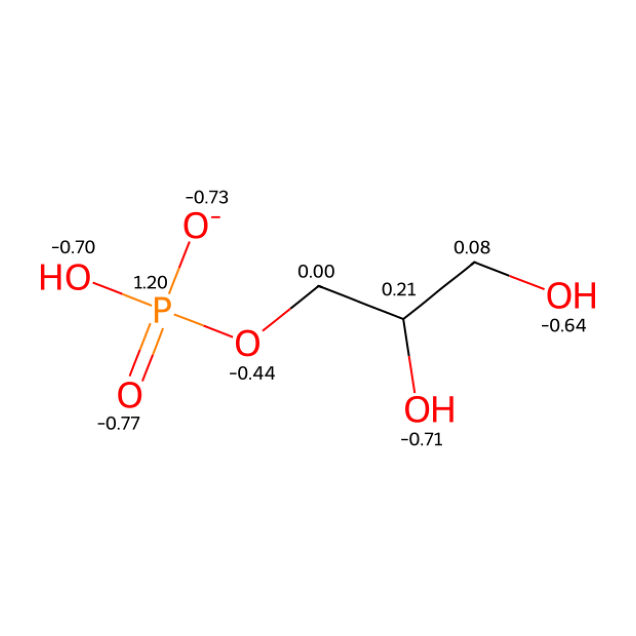

SMILES: C(C(COP(=O)([OH])[O-])O)O  



In [85]:
import sys
import os
import IPython
from IPython.display import Image
# from rdkit.Chem.Draw import IPythonConsole

#@title **Review Your RESP Partial Charges**

#@markdown This section displays the RESP charges calculated for your molecule based on the selected parameters.

charge_model = "RESP"

if charge_model == "RESP":
  image_charge = 'smiles_charges.png'
else:
  pass

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread(image_charge)
plt.figure(figsize = (8,8))
imgplot = plt.imshow(img)
plt.axis('off')
plt.show()

# Image('smiles.png')
a_file = open('/content/smiles.smi')
file_contents = a_file.read()
print("SMILES:", file_contents)

In [81]:
#@title **Parameters to Generate Molecular Topology Using GAFF2 Force Field**

#@markdown Specify the settings and options to build the molecular topology with the GAFF2 force field.

# if os.path.exists(os.path.join(workDir, "tleap_gaff")):
#   cmd.delete("all")
# else:
#   os.mkdir(os.path.join(workDir, "tleap_gaff"))


charge_model = "RESP" #@param ["AM1-BCC", "RESP"]


import os
import subprocess
import shutil

def replace_charge_values(file1_path, file2_path, output_file_path):
      with open(file1_path, 'r') as file:
          content_file1 = file.readlines()

      with open(file2_path, 'r') as file:
          content_file2 = file.readlines()

      # Extract charges from the second file
      charges = []
      in_atom_block = False
      for line in content_file2:
          if line.startswith("@<TRIPOS>ATOM"):
              in_atom_block = True
          elif line.startswith("@<TRIPOS>BOND"):
              in_atom_block = False
          elif in_atom_block:
              parts = line.split()
              if len(parts) >= 9:  # Make sure there is a charge column
                  charges.append(parts[-1])  # Assume the charge is the last column

      # Replace charges in the first file without altering the formatting
      modified_content = []
      in_atom_block = False
      charge_index = 0
      for line in content_file1:
          if line.startswith("@<TRIPOS>ATOM"):
              in_atom_block = True
              modified_content.append(line)
              continue
          elif line.startswith("@<TRIPOS>BOND"):
              in_atom_block = False
              modified_content.append(line)
              continue

          if in_atom_block:
              parts = line.split()
              if len(parts) >= 9 and charge_index < len(charges):  # Make sure there is a charge to replace
                  # Replace only the charge value, keep everything else unchanged
                  new_charge = charges[charge_index]
                  charge_index += 1
                  # The following line constructs a new line where only the charge value is updated
                  line = line.rstrip('\n')  # Remove newline character to work with the end of the line
                  last_space_index = line.rfind(' ')  # Find the last space before the original charge
                  line = line[:last_space_index] + ' ' + new_charge  # Replace the charge
              modified_content.append(line + '\n')  # Add back the newline character
          else:
              modified_content.append(line)

      # Write the modified content to a new file
      with open(output_file_path, 'w') as file:
          file.writelines(modified_content)

# Assuming workDir is defined somewhere above this code
base_dir = os.path.join(workDir, "tleap_gaff")
if not os.path.exists(base_dir):
    os.makedirs(base_dir)

# Define all paths at once for cleaner code
paths = {
    "tleap_in": os.path.join(base_dir, "tleap.in"),
    "SYS_prmtop": os.path.join(base_dir, "SYS.prmtop"),
    "SYS_crd": os.path.join(base_dir, "SYS.crd"),
    "SYS_pdb": os.path.join(base_dir, "SYS.pdb"),
    "ligand_pdb": os.path.join(workDir, "smiles_min.pdb"),
    "ligand_noh": os.path.join(base_dir, "ligand_noh.pdb"),
    "ligand_mol2": os.path.join(base_dir, "ligand.mol2"),
    "ligand_new": os.path.join(base_dir, "new.mol2"),
    # "ligand_frcmod": os.path.join(base_dir, "ligand.frcmod"),
    "ligand_gaff": os.path.join(base_dir, "ligand_gaff.pdb"),
    "protein_ligand": os.path.join(base_dir, "protein_ligand.pdb"),
    "lig_lib": os.path.join(base_dir, "lig.lib"),
    "charge_gaff": charges,
}


def run_shell_command(command, silent=True):
    """Execute a shell command optionally in silent mode."""
    if silent:
        command += " >/dev/null 2>&1"
    subprocess.run(command, shell=True)

def write_file(path, content):
    """Write content to a file."""
    with open(path, 'w') as file:
        file.write(content)

path_frcmod = {
    "ligand_frcmod": os.path.join(base_dir, "ligand.frcmod"),
}

if charge_model == "RESP":

  gaff_commands = [
      f"pdb4amber -i {paths['ligand_pdb']} -o {paths['ligand_noh']}",
      f"antechamber -i {paths['ligand_noh']} -fi pdb -o {paths['ligand_mol2']} -fo mol2 -nc {paths['charge_gaff']} -rn LIG -at gaff2",
      f"parmchk2 -i {paths['ligand_mol2']} -f mol2 -o {path_frcmod['ligand_frcmod']} -s gaff2 -a Y "
  ]

  # Running gaff commands
  write_file('gaff.sh', "\n".join(gaff_commands))
  run_shell_command("chmod 700 gaff.sh")
  run_shell_command("bash gaff.sh")

  # Replace the paths with your actual file paths
  file1_path = f"{paths['ligand_mol2']}"
  file2_path = '/content/_partialChgs.mol2'
  output_file_path = f"{paths['ligand_new']}"

  replace_charge_values(file1_path, file2_path, output_file_path)

else:

  gaff_commands = [
      f"pdb4amber -i {paths['ligand_pdb']} -o {paths['ligand_noh']}",
      f"antechamber -i {paths['ligand_noh']} -fi pdb -o {paths['ligand_mol2']} -fo mol2 -nc {paths['charge_gaff']} -rn LIG -at gaff2 -c bcc",
      f"parmchk2 -i {paths['ligand_mol2']} -f mol2 -o {path_frcmod['ligand_frcmod']} -s gaff2 -a Y "
  ]

  # Running gaff commands
  write_file('gaff.sh', "\n".join(gaff_commands))
  run_shell_command("chmod 700 gaff.sh")
  run_shell_command("bash gaff.sh")
  shutil.copyfile(os.path.join(base_dir, "ligand.mol2"), os.path.join(base_dir, "new.mol2"))

# Preparing tLeap commands
tleap_commands_first_part = f"""source leaprc.protein.ff19SB
source leaprc.gaff2
LIG = loadmol2 {paths['ligand_new']}
loadamberparams {path_frcmod['ligand_frcmod']}
saveoff LIG {paths['lig_lib']}
savepdb LIG {paths['ligand_gaff']}
quit"""

write_file(paths['tleap_in'], tleap_commands_first_part)

# Running the first part of tLeap
run_shell_command(f"tleap -f {paths['tleap_in']}")

# Preparing the second part of tLeap commands
tleap_commands_second_part = f"""source leaprc.protein.ff19SB
source leaprc.DNA.OL15
source leaprc.RNA.OL3
source leaprc.GLYCAM_06j-1
source leaprc.gaff2
loadamberparams {path_frcmod['ligand_frcmod']}
loadoff {paths['lig_lib']}
SYS = loadmol2 {paths['ligand_new']}
alignaxes SYS
check SYS
charge SYS
set SYS box {{50,50,50}}
saveamberparm SYS {paths['SYS_prmtop']} {paths['SYS_crd']}
savepdb SYS {paths['SYS_pdb']}
quit"""

write_file(paths['tleap_in'], tleap_commands_second_part)

# Running the second part of tLeap
run_shell_command(f"tleap -f {paths['tleap_in']}")

# Verifying the outputs
if all(os.path.exists(path) for path in [paths['SYS_pdb'], paths['SYS_prmtop'], paths['SYS_crd']]):
    print("Successfully generated topology! :-)")
else:
    print("ERROR: Check your inputs!")

# Cleanup
# run_shell_command("rm *.sh ANTECHAMBER* ATOMTYPE* temp.txt")

Successfully generated topology! :-)


In [76]:
#@title **Download the files**:

program = "AMBER"

import parmed
import zipfile
from google.colab import files
import locale
local_dir = "/content"
import glob
if program == "AMBER":

  paths_amber = {
      "SYS_prmtop": os.path.join(base_dir, "SYS.prmtop"),
      "SYS_crd": os.path.join(base_dir, "SYS.crd"),
      "SYS_pdb": os.path.join(base_dir, "SYS.pdb"),
      "ligand_mol2": os.path.join(base_dir, "ligand.mol2"),
      "ligand_new": os.path.join(base_dir, "new.mol2"),
      "ligand_frcmod": os.path.join(base_dir, "ligand.frcmod"),
      "ligand_gaff_new": os.path.join(base_dir, "ligand_gaff.pdb"),
      "lig_lib": os.path.join(base_dir, "lig.lib"),
  }


  amber_top = os.path.exists(paths_amber["SYS_prmtop"])
  amber_crd = os.path.exists(paths_amber["SYS_crd"])
  amber_pdb = os.path.exists(paths_amber["SYS_pdb"])
  amber_mol2 = os.path.exists(paths_amber["ligand_mol2"])
  amber_new = os.path.exists(paths_amber["ligand_new"])
  amber_frcmod = os.path.exists(paths_amber["ligand_frcmod"])
  amber_gaff_new = os.path.exists(paths_amber["ligand_gaff_new"])
  amber_lib = os.path.exists(paths_amber["lig_lib"])

  if amber_top and amber_crd and amber_pdb and amber_mol2 and amber_new and amber_frcmod and amber_gaff_new and amber_lib:
      # Define the name of the zip file
      zip_file_name = "amber.zip"

      # Create the zip file and add files
      with zipfile.ZipFile(zip_file_name, 'w') as zipf:  # Open in append mode
          existing_files = zipf.namelist()  # Get a list of existing files in the zip

          # Add topology files
          for file_key, file_path in paths_amber.items():
              file_name = os.path.basename(file_path)
              if os.path.exists(file_path) and f"topology/{file_name}" not in existing_files:  # Check if the file exists and not already in the zip
                  zipf.write(file_path, arcname=f"topology/{file_name}")

          for png_file in glob.glob(os.path.join( "*.png")):
              file_name = os.path.basename(png_file)
              if f"images/{file_name}" not in existing_files:  # Check if the file is not already in the zip
                  zipf.write(png_file, arcname=f"images/{file_name}")

          for dat_file in glob.glob(os.path.join( "*.dat")):
              file_name = os.path.basename(dat_file)
              if f"raw_files/{file_name}" not in existing_files:  # Check if the file is not already in the zip
                  zipf.write(dat_file, arcname=f"raw_files/{file_name}")

          for smi_file in glob.glob(os.path.join( "*.smi")):
              file_name = os.path.basename(smi_file)
              if f"raw_files/{file_name}" not in existing_files:  # Check if the file is not already in the zip
                  zipf.write(smi_file, arcname=f"raw_files/{file_name}")


          for mol_file in glob.glob(os.path.join( "*.mol")):
              file_name = os.path.basename(mol_file)
              if f"mol_files/{file_name}" not in existing_files:  # Check if the file is not already in the zip
                  zipf.write(mol_file, arcname=f"mol_files/{file_name}")

          for pdb_file in glob.glob(os.path.join( "*.pdb")):
              file_name = os.path.basename(pdb_file)
              if f"mol_files/{file_name}" not in existing_files:  # Check if the file is not already in the zip
                  zipf.write(pdb_file, arcname=f"pdb_files/{file_name}")

          for xyz_file in glob.glob(os.path.join( "*.xyz")):
              file_name = os.path.basename(xyz_file)
              if f"xyz_files/{file_name}" not in existing_files:  # Check if the file is not already in the zip
                  zipf.write(xyz_file, arcname=f"xyz_files/{file_name}")

          for mol2_file in glob.glob(os.path.join( "*.mol2")):
              file_name = os.path.basename(mol2_file)
              if f"mol2_files/{file_name}" not in existing_files:  # Check if the file is not already in the zip
                  zipf.write(mol2_file, arcname=f"mol2_files/{file_name}")

      files.download('amber.zip')

      print("Successfully generated topology! :-)")
  else:
      print("ERROR: Check your inputs! ")

else:
  pass


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully generated topology! :-)
